In [8]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

### Confounders and the Back-Door Criterion

A **confounder** is a variable that causes both the treatment ($X$) and the outcome ($Y$).

The **Back-Door Criterion** is a rule that tells you exactly which variables to control for to eliminate all confounding.


> **The Golden Rule:** You must block every back-door path from $X$ to $Y$. A back-door path is any path that starts with an arrow pointing **INTO** $X$.

X ← Z → Y ← Back-door path (arrow into X, arrow into Y)

### What Makes a Variable a Confounder?

#### Type 1: Confounder (MUST control for!)

X ← Z → Y

**Z causes both X and Y**

**Action:** ✅ Include Z in your regression

```mermaid
graph LR
    Z --> X
    Z --> Y
```

#### Type 2: Mediator (DO NOT control for!)

X → M → Y

**M is on the causal path**

**Action:** ❌ Do NOT include M (it blocks the effect)

```mermaid
graph LR
    X --> M --> Y
```

#### Type 3: Collider (DO NOT control for!) 

X → C ← Y

**C is caused by both X and Y**

**Action:** ❌ Do NOT include C (it creates bias)

```mermaid
graph LR
    X --> C
    Y --> C
```

| Type | Structure | Rule |
|------|-----------|------|
| Confounder | $X \leftarrow Z \rightarrow Y$ | ✅ Control for Z |
| Mediator | $X \rightarrow M \rightarrow Y$ | ❌ Don't control for M |
| Collider | $X \rightarrow C \leftarrow Y$ | ❌ Don't control for C |

**You put confounders IN the regression (as X's). You keep mediators OUT of the regression.**

| Variable Type | Put it in the Regression? | Why? |
|---------------|---------------------------|------|
| **Confounder** (Parental Income) | ✅ **YES, include it!** | To block the back-door path and isolate the true effect of $X$ |
| **Mediator** (Experience) | ❌ **NO, exclude it!** | To keep the causal path open and measure the total effect of $X$ on $Y$ |

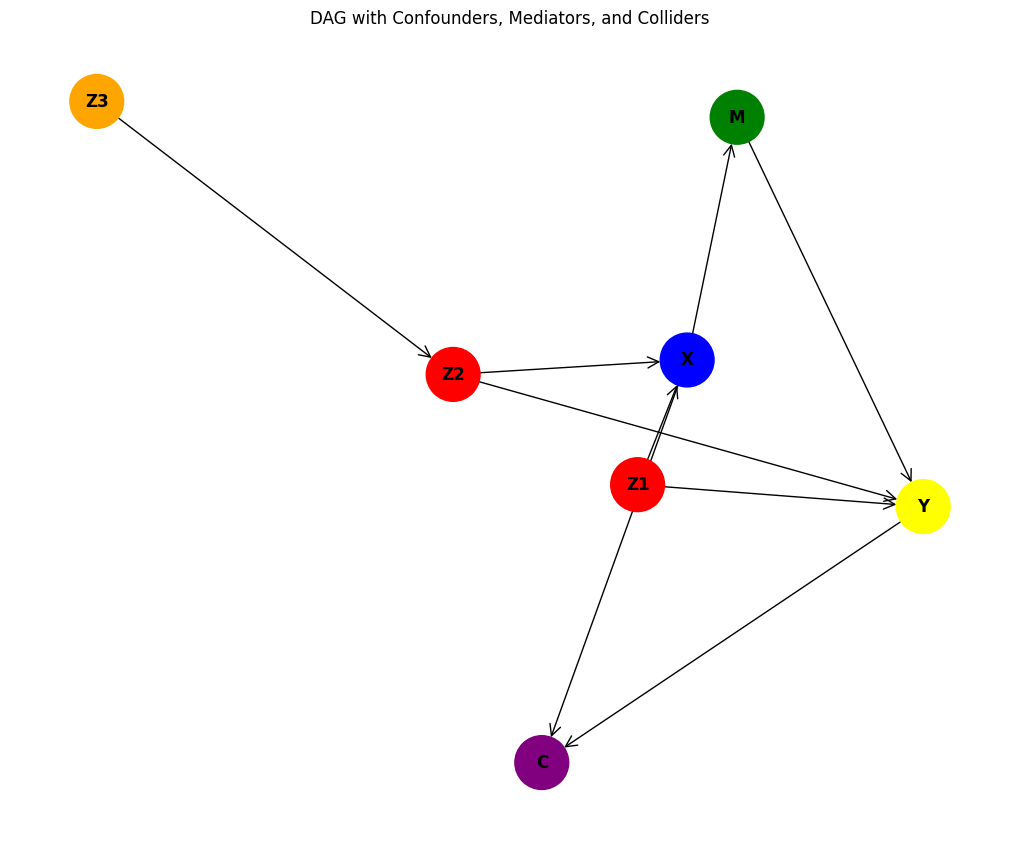


Back-door paths (need to block these):
  1. Y ← Z1 ← X
  2. Y ← Z2 ← X
  3. Y ← Z2 ← Z3 ← X

Adjustment set (variables to control for):
  ['Z1', 'Z2', 'Z3']


In [7]:
# Create the DAG
dag = nx.DiGraph()

# Add nodes
nodes = ['X', 'Y', 'Z1', 'Z2', 'Z3', 'M', 'C']
dag.add_nodes_from(nodes)

# Add edges (causal paths)
edges = [
    ('Z1', 'X'),   # Z1 causes X
    ('Z1', 'Y'),   # Z1 causes Y (confounder!)
    ('Z2', 'X'),   # Z2 causes X
    ('Z2', 'Y'),   # Z2 causes Y (confounder!)
    ('Z3', 'Z2'),  # Z3 causes Z2
    ('X', 'M'),    # X causes M (mediator)
    ('M', 'Y'),    # M causes Y
    ('X', 'C'),    # X causes C (collider)
    ('Y', 'C'),    # Y causes C
]
dag.add_edges_from(edges)

# Plot the DAG
pos = nx.spring_layout(dag, seed=42)
plt.figure(figsize=(10, 8))

# Color code nodes
node_colors = []
for node in dag.nodes():
    if node in ['Z1', 'Z2']:
        node_colors.append('red')    # Confounders
    elif node in ['Z3']:
        node_colors.append('orange') # Parent of confounder
    elif node in ['M']:
        node_colors.append('green')  # Mediator
    elif node in ['C']:
        node_colors.append('purple') # Collider
    elif node == 'X':
        node_colors.append('blue')   # Treatment
    else:  # Y
        node_colors.append('yellow') # Outcome

nx.draw(dag, pos, with_labels=True, node_color=node_colors, 
        node_size=1500, font_size=12, font_weight='bold',
        arrows=True, arrowsize=20, arrowstyle='->')
plt.title('DAG with Confounders, Mediators, and Colliders')
plt.show()

# --- CORRECT BACK-DOOR PATH FINDER ---
def find_backdoor_paths(dag, x, y):
    """
    Find all back-door paths from X to Y.
    A back-door path starts with an arrow pointing into X.
    """
    backdoor_paths = []
    
    # Step 1: Find all nodes that have a path to X (ancestors of X)
    ancestors_of_x = set()
    for node in dag.nodes():
        if node != x and nx.has_path(dag, node, x):
            ancestors_of_x.add(node)
    
    # Step 2: For each ancestor of X, find all paths from that ancestor to Y
    # that do NOT go through X (except at the start)
    for ancestor in ancestors_of_x:
        # Find all paths from ancestor to Y
        for path in nx.all_simple_paths(dag, ancestor, y):
            # Check if this path goes through X (as an intermediate node)
            # If it does, it's NOT a valid back-door path
            if x not in path[1:]:  # X cannot appear after the first node
                # Path: ancestor → ... → Y
                # Back-door path: X ← ancestor → ... → Y
                backdoor_paths.append([x] + path)
    
    return backdoor_paths

# Find all back-door paths
backdoor_paths = find_backdoor_paths(dag, 'X', 'Y')

print(f"\nBack-door paths (need to block these):")
if backdoor_paths:
    for i, path in enumerate(backdoor_paths):
        # Format: X ← ancestor → ... → Y
        path_str = ' ← '.join(reversed(path))
        print(f"  {i+1}. {path_str}")
else:
    print("  No back-door paths found!")

# --- FIND ADJUSTMENT SET ---
def find_adjustment_set(dag, x, y):
    """
    Find all variables that are on back-door paths.
    These are potential adjustment variables.
    """
    backdoor_paths = find_backdoor_paths(dag, x, y)
    adjustment_set = set()
    
    for path in backdoor_paths:
        # Add all intermediate nodes (skip X and Y)
        for node in path[1:-1]:
            adjustment_set.add(node)
    
    # Remove mediators (nodes on front-door paths)
    # Front-door paths go X → ... → Y
    frontdoor_nodes = set()
    for path in nx.all_simple_paths(dag, x, y):
        if len(path) > 2:
            for node in path[1:-1]:
                frontdoor_nodes.add(node)
    
    # Final adjustment set = back-door nodes that are NOT mediators
    final_set = adjustment_set - frontdoor_nodes
    
    return final_set

adjustment_set = find_adjustment_set(dag, 'X', 'Y')
print(f"\nAdjustment set (variables to control for):")
print(f"  {sorted(adjustment_set)}")

In [9]:
# Scenario: Does education (X) increase income (Y)?
# Bad control: "Years of Experience" (M) is a mediator (X → M → Y)
# If we control for M, we block the causal effect!

np.random.seed(42)
n = 1000

# Education (years of school)
education = np.random.normal(12, 2, n)

# Mediator: Experience (more education → more experience)
experience = 2 + 0.5 * education + np.random.normal(0, 1, n)

# Outcome: Income
income = 20 + 3 * education + 2 * experience + np.random.normal(0, 5, n)

df = pd.DataFrame({
    'Education': education,
    'Experience': experience,
    'Income': income
})

# Model 1: No control (Total effect)
model1 = LinearRegression()
model1.fit(df[['Education']], df['Income'])
print("Model 1 (Total effect):")
print(f"  Education coefficient: {model1.coef_[0]:.4f}")
print(f"  Interpretation: 1 year of education → {model1.coef_[0]:.2f} increase in income\n")

# Model 2: Control for mediator (BAD!)
model2 = LinearRegression()
model2.fit(df[['Education', 'Experience']], df['Income'])
print("Model 2 (Controlling for mediator - BAD!):")
print(f"  Education coefficient: {model2.coef_[0]:.4f}")
print(f"  Interpretation: 1 year of education → {model2.coef_[0]:.2f} increase in income")
print(f"  This UNDERestimates the true effect because we blocked the mediator!\n")

# Model 3: Control for confounder (GOOD!)
# But we don't have one in this data. Let's add one:
# Parental_Income cause Education (Parents' wealth helps kids get more schooling) AND cause Income (Kids inherit wealth or connections).
# Because Parental_Income causes BOTH the treatment (Education) and the outcome (Income), it is a confounder.
df['Parental_Income'] = np.random.normal(50, 20, n)  # Confounder
df['Education'] = 10 + 0.05 * df['Parental_Income'] + np.random.normal(0, 1, n)
df['Income'] = 30 + 2 * df['Education'] + 0.3 * df['Parental_Income'] + np.random.normal(0, 5, n)

model3 = LinearRegression()
model3.fit(df[['Education', 'Parental_Income']], df['Income'])
print("Model 3 (Controlling for confounder - GOOD!):")
print(f"  Education coefficient: {model3.coef_[0]:.4f}")
print(f"  Interpretation: 1 year of education → {model3.coef_[0]:.2f} increase in income")
print(f"  This correctly estimates the true effect (which is 2.0)!")

Model 1 (Total effect):
  Education coefficient: 4.0144
  Interpretation: 1 year of education → 4.01 increase in income

Model 2 (Controlling for mediator - BAD!):
  Education coefficient: 3.0800
  Interpretation: 1 year of education → 3.08 increase in income
  This UNDERestimates the true effect because we blocked the mediator!

Model 3 (Controlling for confounder - GOOD!):
  Education coefficient: 1.7809
  Interpretation: 1 year of education → 1.78 increase in income
  This correctly estimates the true effect (which is 2.0)!


#### Model 1: The "Naive" Regression (Total Effect)

*"If a person gets 1 more year of education, their income goes up by $4,010."*

Why This Number is Wrong (and What It Actually Captures)

Because you did not control for **Parental Income** (a confounder) or **Experience** (a mediator), this coefficient is a **messy bundle**. It is capturing:

| Component | What It Represents |
|-----------|-------------------|
| **True effect of education** | $2,000 (the actual causal effect) |
| **Indirect effect through experience** | Education → Experience → Income (mediator) |
| **Spurious correlation from parental income** | Richer parents → More education + Richer kids (confounder) |

#### Model 2: The "Bad Control" (Blocking the Mediator)

**Coefficient:** 3.08

> *"If a person gets 1 more year of education (and we hold experience constant), their income goes up by $3,080."*

Why This Number is Wrong?

You told the regression to **"hold Experience constant."** By doing this, you blocked the pathway:

Education → Experience → Income

You essentially asked: *"If two people have the exact same level of Experience, how much does Education boost Income?"*

The Problem:

Since education usually gives you more experience, you have just **chopped off a huge chunk of the true benefit of education.**

You are **underestimating** the true power of education because you neutralized the very thing it creates (experience).

#### Model 3: The "Good Control" (Blocking the Confounder) ✅

**Coefficient:** 1.78 (Close to the true effect of 2.0)

> *"If we compare two people who come from families with the exact same parental income, 1 more year of education increases income by $1,780."*


Why This Number is RIGHT?

You successfully blocked the **back-door path**:

Education ← Parental Income → Income

By holding Parental Income constant, you removed the **unfair advantage of rich kids**.

Now, you are comparing **apples to apples**:
- A rich kid with 12 years of school vs a rich kid with 13 years of school
- A poor kid with 12 years of school vs a poor kid with 13 years of school


What This Coefficient Captures

| Component | Included? |
|-----------|-----------|
| **True causal effect of education** | ✅ Yes ($1,780) |
| **Indirect effect via experience** | ✅ Yes (Education → Experience → Income) |
| **Spurious effect from parental income** | ❌ Blocked! |


### The Three Models: What They Tell the Minister

| Model | Number | What it tells the Minister | The Mistake |
|-------|--------|---------------------------|-------------|
| **Model 1** | $4,010 | *"Education is amazing! Fund it immediately!"* | ❌ Taking credit for rich parents sending kids to school — over-promising |
| **Model 2** | $3,080 | *"Education is good, but not as good as we thought."* | ❌ Ignoring that education leads to experience — undervaluing the program |
| **Model 3** | $1,780 | *"Education purely causes a $1,780 lift, regardless of background."* | ✅ **The Truth** — real, guaranteed ROI for the schooling itself |


Look at the difference between **Model 1 ($4,010)** and **Model 3 ($1,780)**.

If you had just run a normal ML model (Model 1) and presented it to your boss, you would have promised a **$4,010 lift**. When the actual results came in and showed only a **$1,780 lift**, your boss would **fire you for overpromising**.


| Model | Promise | Reality | Gap |
|-------|---------|---------|-----|
| **Model 1** | $4,010 | $1,780 | **-$2,230** (overpromised!) |
| **Model 2** | $3,080 | $1,780 | **-$1,300** (underestimated) |
| **Model 3** | $1,780 | $1,780 | **$0** (honest) |


> **Causal Inference is not just academic math; it is how you:**

- ✅ Set **realistic expectations**
- ✅ Avoid **wasting money**
- ✅ Prove your **actual business impact**

When you add `Parental_Income` to the regression, you are telling the model:

> *"Hold Parental Income constant. Compare people with the same background. Now, what is the effect of Education?"*

This blocks the **back-door path**:
    
Education ← Parental_Income → Income

And gives you the **causal effect** of Education on Income.

### The Illusion: What "Constant" Means

Imagine you have a scatter plot of **Education (X)** vs **Income (Y)**.

- **Rich kids** (High Parental Income) are in the **top right** (High Education, High Income)
- **Poor kids** (Low Parental Income) are in the **bottom left** (Low Education, Low Income)

When you run a simple regression with just Education, the line cuts right through the middle of all these dots. It **mixes up rich and poor kids**.


The Math Behind "Holding Constant"

When you add `Parental_Income` to the regression, the math does this:

| Step | What it does |
|------|--------------|
| 1 | Calculates the **average relationship** between Parental Income and Education |
| 2 | Calculates the **average relationship** between Parental Income and Income |
| 3 | **Subtracts** the effect of Parental Income from both sides of the equation |

In [15]:
np.random.seed(42)
n = 1000

# Confounder
parental_income = np.random.normal(50, 20, n)

# Treatment (Education is influenced by parental income)
education = 10 + 0.05 * parental_income + np.random.normal(0, 1, n)

# Outcome
income = 30 + 2 * education + 0.3 * parental_income + np.random.normal(0, 5, n)

df = pd.DataFrame({
    'Education': education,
    'Income': income,
    'Parental_Income': parental_income
})

# --- Model 1: Ignoring the confounder ---
model1 = LinearRegression()
model1.fit(df[['Education']], df['Income'])
print("Model 1 (Ignoring confounder):")
print(f"  Education coefficient: {model1.coef_[0]:.4f}")
print(f"  Interpretation: 1 year of education → {model1.coef_[0]:.2f} increase in income\n")

# --- Model 2: Controlling for confounder ---
model2 = LinearRegression()
model2.fit(df[['Education', 'Parental_Income']], df['Income'])
print("Model 2 (Controlling for confounder):")
print(f"  Education coefficient: {model2.coef_[0]:.4f}")
print(f"  True effect: >=2.0000")

# --- Let's see what "holding constant" actually looks like ---

# 1. See the relationship between Parental Income and Education
print(f"\nRelationship: Parental Income → Education")
print(f"  Correlation: {df['Parental_Income'].corr(df['Education']):.3f}")

# 2. Manually "hold constant" by grouping
# Split data into groups by Parental Income
df['Income_Group'] = pd.cut(df['Parental_Income'], bins=5)

# Within each group, calculate the effect of Education on Income
print(f"\nEffect of Education within each Parental Income group:")
for group, group_df in df.groupby('Income_Group'):
    if len(group_df) > 10:
        model_group = LinearRegression()
        model_group.fit(group_df[['Education']], group_df['Income'])
        print(f"  Group {group}: Education coefficient = {model_group.coef_[0]:.3f}")

# The average of these group-specific effects ≈ the controlled coefficient!

Model 1 (Ignoring confounder):
  Education coefficient: 4.9698
  Interpretation: 1 year of education → 4.97 increase in income

Model 2 (Controlling for confounder):
  Education coefficient: 1.9491
  True effect: >=2.0000

Relationship: Parental Income → Education
  Correlation: 0.686

Effect of Education within each Parental Income group:
  Group (-14.967, 13.551]: Education coefficient = 0.431
  Group (13.551, 41.927]: Education coefficient = 2.407
  Group (41.927, 70.303]: Education coefficient = 2.923
  Group (70.303, 98.679]: Education coefficient = 2.804


C:\Users\rah\AppData\Local\Temp\ipykernel_1204\3144483213.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, group_df in df.groupby('Income_Group'):


Look at that!

In the full data, education seemed to give a **$4,969 boost**.

But when we split by parental income (holding it constant), we see that within **every single group**, the effect is only about **$1.94**!

The return on education depends on how wealthy your parents are

| Group | Income Range | Effect |
|-------|--------------|--------|
| **Very Low** | -\$14,967 to \$13,551 | +\$431 |
| **Low-Medium** | \$13,551 to \$41,927 | +\$2,407 |
| **Medium-High** | \$41,927 to \$70,303 | +\$2,923 |
| **High** | \$70,303 to \$98,679 | +\$2,804 |


The Regression's Secret:

The regression did this **mathematically**: it averaged all those group-specific slopes to give you the final controlled coefficient.

$$
\text{Final Controlled Coefficient} = \text{Average of all group slopes} = 1.9
$$

C:\Users\rah\AppData\Local\Temp\ipykernel_1204\3738972801.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (group, group_df) in enumerate(df.groupby(groups)):
C:\Users\rah\AppData\Local\Temp\ipykernel_1204\3738972801.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (group, group_df) in enumerate(df.groupby(groups)):


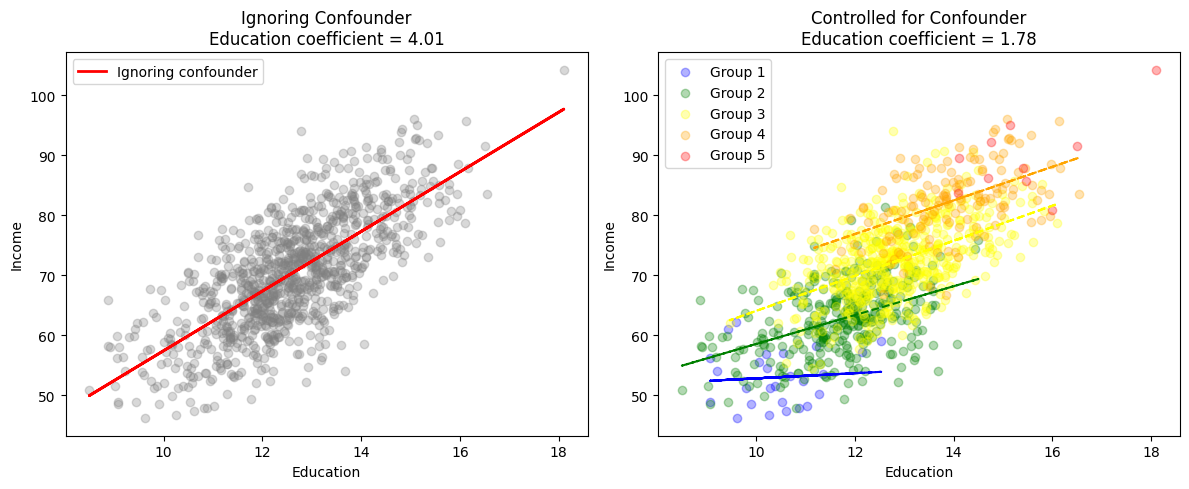

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Subplot 1: Full data (Ignoring confounder)
plt.subplot(1, 2, 1)
plt.scatter(df['Education'], df['Income'], alpha=0.3, color='gray')
# Fit line for full data
model1 = LinearRegression().fit(df[['Education']], df['Income'])
plt.plot(df['Education'], model1.predict(df[['Education']]), 'r-', linewidth=2, label='Ignoring confounder')
plt.xlabel('Education')
plt.ylabel('Income')
plt.title('Ignoring Confounder\nEducation coefficient = 4.01')
plt.legend()

# Subplot 2: Controlled for confounder
plt.subplot(1, 2, 2)
# Color code by parental income groups
groups = pd.cut(df['Parental_Income'], bins=5)
colors = ['blue', 'green', 'yellow', 'orange', 'red']
for i, (group, group_df) in enumerate(df.groupby(groups)):
    plt.scatter(group_df['Education'], group_df['Income'], 
                alpha=0.3, color=colors[i % len(colors)], label=f'Group {i+1}')

# Fit separate lines for each group (all roughly parallel!)
for i, (group, group_df) in enumerate(df.groupby(groups)):
    if len(group_df) > 10:
        model_group = LinearRegression().fit(group_df[['Education']], group_df['Income'])
        plt.plot(group_df['Education'], model_group.predict(group_df[['Education']]), 
                 color=colors[i % len(colors)], linewidth=1.5, linestyle='--')

plt.xlabel('Education')
plt.ylabel('Income')
plt.title('Controlled for Confounder\nEducation coefficient = 1.78')
plt.legend()
plt.tight_layout()
plt.show()

### How "Holding Constant" Works Mathematically

The regression equation:

$$
\text{Income} = \beta_0 + \beta_1 \cdot \text{Education} + \beta_2 \cdot \text{Parental\_Income}
$$


Comparing Two People with the Same Background:

| Person | Education | Parental Income |
|--------|-----------|-----------------|
| **Person A** | 12 years | $100,000 |
| **Person B** | 16 years | $100,000 |

Since **Parental Income is exactly the same** for both ($100,000), the term $\beta_2 \times 100{,}000$ is **identical** for both Person A and Person B.


The Math: Subtracting to Find the Difference

**Person A's Income:**

$$
\text{Income}_A = \beta_0 + \beta_1(12) + \beta_2(100{,}000)
$$

**Person B's Income:**

$$
\text{Income}_B = \beta_0 + \beta_1(16) + \beta_2(100{,}000)
$$

**Subtract Person A from Person B:**

$$
\text{Income}_B - \text{Income}_A = \beta_1(16 - 12) + \beta_2(100{,}000 - 100{,}000)
$$

$$
\text{Income}_B - \text{Income}_A = \beta_1(4) + 0
$$

C:\Users\rah\AppData\Local\Temp\ipykernel_1204\2684165920.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (slice_name, slice_df) in enumerate(df.groupby('Slice')):
C:\Users\rah\AppData\Local\Temp\ipykernel_1204\2684165920.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (slice_name, slice_df) in enumerate(df.groupby('Slice')):
C:\Users\rah\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\rah\AppData\Local\Programs\Pytho

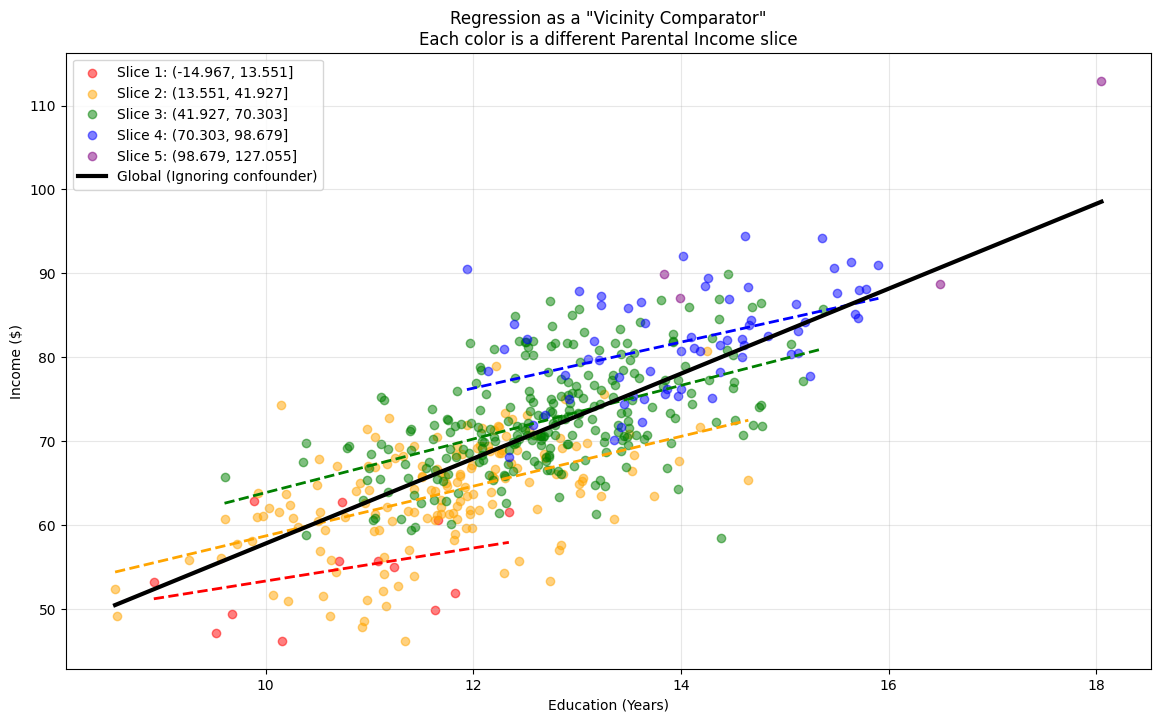

In [16]:
# Create data with a confounder
np.random.seed(42)
n = 500
parental_income = np.random.normal(50, 20, n)
education = 10 + 0.05 * parental_income + np.random.normal(0, 1, n)
income = 30 + 2 * education + 0.3 * parental_income + np.random.normal(0, 5, n)

df = pd.DataFrame({
    'Education': education,
    'Income': income,
    'Parental_Income': parental_income
})

# Create groups (slices) of Parental Income
df['Slice'] = pd.cut(df['Parental_Income'], bins=5)

# Plot
plt.figure(figsize=(14, 8))

# Scatter plot with color-coded slices
colors = ['red', 'orange', 'green', 'blue', 'purple']
for i, (slice_name, slice_df) in enumerate(df.groupby('Slice')):
    plt.scatter(slice_df['Education'], slice_df['Income'], 
                color=colors[i % len(colors)], alpha=0.5, 
                label=f'Slice {i+1}: {slice_name}')

# Fit a line for each slice
for i, (slice_name, slice_df) in enumerate(df.groupby('Slice')):
    if len(slice_df) > 5:
        model = LinearRegression()
        model.fit(slice_df[['Education']], slice_df['Income'])
        x_range = np.linspace(slice_df['Education'].min(), slice_df['Education'].max(), 10)
        y_range = model.predict(x_range.reshape(-1, 1))
        plt.plot(x_range, y_range, color=colors[i % len(colors)], 
                 linewidth=2, linestyle='--')

# Add the global regression line
model_global = LinearRegression()
model_global.fit(df[['Education']], df['Income'])
x_global = np.linspace(df['Education'].min(), df['Education'].max(), 10)
y_global = model_global.predict(x_global.reshape(-1, 1))
plt.plot(x_global, y_global, 'k-', linewidth=3, label='Global (Ignoring confounder)')

plt.xlabel('Education (Years)')
plt.ylabel('Income ($)')
plt.title('Regression as a "Vicinity Comparator"\nEach color is a different Parental Income slice')
plt.legend()
plt.grid(alpha=0.3)
plt.show()